DATASCI 151 Group Project
Student ID Numbers: Alec Anghel (2697818)

# F1 Driver Performance and Lap Times Analysis

### Introduction
Formula 1 (F1) is a high level competitive sport, where both the performance of the driver, and the car built play an important role in the result of the team. As a result, a lot of data analysis and statistical understanding of the sport can be used to better understand what drives an winning team, vs a losing one. What makes a team better, and what can a team do to improve their results. This project investiates two main questions regarding historical F1 data. 1. Does a driver's nationality correlate with a faster lap time? and 2. At what age to F1 drivers reach their peak performances?

By looking at driver demographics, race dates, and over 500,000 individual lap times, it was made pretty clear that Canadian and Italian drivers hold the fastest historical average pace. On top of that, our analysis shows a clear aging curve, showing drivers reach their peak speed between the ages of 26 and 32. The project is structured by first introducing and cleaning the datasets, followed by a grouped analysis of nationality and pace, and finishing with an analysis of driver age.

In [1]:
# importing packages
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### Data Description
The data for this project came from a Formula 1 dataset found on Kaggle. Three main tables were used for this analysis
"drivers.csv": A file that holds observations of driver demographics. It cotains their names, dates of brith, and nantionalities
"lap_times.csv": A file that contains observations of individual lap times, race IDs, and milliseconds recorded.
"races.csv": A data set that contains race dates. This will be used to find the drivers exact age.

In [2]:
# loading the datasets
drivers = pd.read_csv("f1_data\drivers.csv")
lap_times = pd.read_csv("f1_data\lap_times.csv")

display(drivers)
display(lap_times)

,driverId,driverRef,number,code,forename,surname,dob,nationality,url
0,1,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton
1,2,heidfeld,\N,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld
2,3,rosberg,6,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg
3,4,alonso,14,ALO,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso
4,5,kovalainen,\N,KOV,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen
...,...,...,...,...,...,...,...,...,...
849,851,aitken,89,AIT,Jack,Aitken,1995-09-23,British,http://en.wikipedia.org/wiki/Jack_Aitken
850,852,tsunoda,22,TSU,Yuki,Tsunoda,2000-05-11,Japanese,http://en.wikipedia.org/wiki/Yuki_Tsunoda
851,853,mazepin,9,MAZ,Nikita,Mazepin,1999-03-02,Russian,http://en.wikipedia.org/wiki/Nikita_Mazepin
852,854,mick_schumacher,47,MSC,Mick,Schumacher,1999-03-22,German,http://en.wikipedia.org/wiki/Mick_Schumacher


,raceId,driverId,lap,position,time,milliseconds
0,841,20,1,1,1:38.109,98109
1,841,20,2,1,1:33.006,93006
2,841,20,3,1,1:32.713,92713
3,841,20,4,1,1:32.803,92803
4,841,20,5,1,1:32.342,92342
...,...,...,...,...,...,...
528780,1086,842,65,13,1:25.989,85989
528781,1086,842,66,12,1:25.187,85187
528782,1086,842,67,12,1:47.355,107355
528783,1086,842,68,12,1:37.587,97587


### Data Cleaning
Before we merge our data, the raw data needs to be cleaned for more accurate statiscal computing. In the drivers table, we replaced missing values ("\N") with "NaN" values, droped the unnecessary URL column, and converted the 'dob' (Date of Birth) column into a usable datetime format. In the lap times table, we created a new column to convert the  "milliseconds" into  "seconds" to make our final plots and tables more understandable.

In [3]:
# First thing to do is to clean the data sets
# Let's first clean the drivers data set

# Replace the \N in the numbers with the NaN value
drivers = drivers.replace(r'\N', np.nan)

# We don't really need the url column so we can drop that
drivers = drivers.drop(columns=['url'])

# Convert the date of birth to an actual date of birth format
drivers['dob'] = pd.to_datetime(drivers['dob'])

# Let's convert the number column into actual numeric values
drivers['number'] = pd.to_numeric(drivers['number'])

display(drivers)

,driverId,driverRef,number,code,forename,surname,dob,nationality
0,1,hamilton,44.0,HAM,Lewis,Hamilton,1985-01-07,British
1,2,heidfeld,NaN,HEI,Nick,Heidfeld,1977-05-10,German
2,3,rosberg,6.0,ROS,Nico,Rosberg,1985-06-27,German
3,4,alonso,14.0,ALO,Fernando,Alonso,1981-07-29,Spanish
4,5,kovalainen,NaN,KOV,Heikki,Kovalainen,1981-10-19,Finnish
...,...,...,...,...,...,...,...,...
849,851,aitken,89.0,AIT,Jack,Aitken,1995-09-23,British
850,852,tsunoda,22.0,TSU,Yuki,Tsunoda,2000-05-11,Japanese
851,853,mazepin,9.0,MAZ,Nikita,Mazepin,1999-03-02,Russian
852,854,mick_schumacher,47.0,MSC,Mick,Schumacher,1999-03-22,German


In [4]:
# Ok now lets clean the lap_times data set
# It already looks pretty clean, only thing I want to do is convert miliseconds into seconds
lap_times['seconds'] = lap_times['milliseconds'] / 1000
display(lap_times)

,raceId,driverId,lap,position,time,milliseconds,seconds
0,841,20,1,1,1:38.109,98109,98.109
1,841,20,2,1,1:33.006,93006,93.006
2,841,20,3,1,1:32.713,92713,92.713
3,841,20,4,1,1:32.803,92803,92.803
4,841,20,5,1,1:32.342,92342,92.342
...,...,...,...,...,...,...,...
528780,1086,842,65,13,1:25.989,85989,85.989
528781,1086,842,66,12,1:25.187,85187,85.187
528782,1086,842,67,12,1:47.355,107355,107.355
528783,1086,842,68,12,1:37.587,97587,97.587


### Merging Procedure
To analyze performance by driver attributes, we have to combine our tables. We performed an inner join on the "lap_times" and "drivers" datasets using the "driverId" column, since it appeared in both datasets. An inner join makes it so that our combined dataset only keeps rows where we have both a valid lap time and the corresponding driver's demographic details.

In [5]:
# Now lets merge the data on the driverID column
# I'm going to use an inner join so that we only keep the rows where we have both the driver's details and a valid lap time
f1_data = pd.merge(lap_times, drivers, on='driverId', how='inner')

display(f1_data)

,raceId,driverId,lap,position,time,milliseconds,seconds,driverRef,number,code,forename,surname,dob,nationality
0,841,20,1,1,1:38.109,98109,98.109,vettel,5.0,VET,Sebastian,Vettel,1987-07-03,German
1,841,20,2,1,1:33.006,93006,93.006,vettel,5.0,VET,Sebastian,Vettel,1987-07-03,German
2,841,20,3,1,1:32.713,92713,92.713,vettel,5.0,VET,Sebastian,Vettel,1987-07-03,German
3,841,20,4,1,1:32.803,92803,92.803,vettel,5.0,VET,Sebastian,Vettel,1987-07-03,German
4,841,20,5,1,1:32.342,92342,92.342,vettel,5.0,VET,Sebastian,Vettel,1987-07-03,German
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
528780,1086,842,65,13,1:25.989,85989,85.989,gasly,10.0,GAS,Pierre,Gasly,1996-02-07,French
528781,1086,842,66,12,1:25.187,85187,85.187,gasly,10.0,GAS,Pierre,Gasly,1996-02-07,French
528782,1086,842,67,12,1:47.355,107355,107.355,gasly,10.0,GAS,Pierre,Gasly,1996-02-07,French
528783,1086,842,68,12,1:37.587,97587,97.587,gasly,10.0,GAS,Pierre,Gasly,1996-02-07,French


### Main Columns and Descriptive Statistics
Our main columns of interest for the analysis are "nationality", "seconds", and later, the driver's calculated "age". Below is a table of descriptive statistics for our seconds variable.

In [6]:
# Compute descriptive statistics for our numerical column and round to 2 decimal places
descriptive_stats = f1_data[['seconds']].describe().round(2)
display(descriptive_stats)

,seconds
count,528785.00
mean,95.68
std,75.34
min,55.40
25%,82.06
50%,90.67
75%,102.21
max,7507.55


## Analysis

### Drivers Pace by Nationality
To learn if drivers from certain countries are actually faster, we should group lap times by driver nationality. To make sure our analysis is make sense, we first filter out laps that don't make sense, or are affected by external factors (such as pit stops, safety cars, or crashes) by capping normal laps at 120 seconds. We should also filter the final table to only include countries with over 10,000 recorded laps to make a fair sample size.

In [7]:
# Now lets do some analysis. I'd like to investiage the relationship between the nationality of a driver and how well on average they do in races
# First we should filter out some abnormally slow laps. Maybe caused by racing cars or other factors
clean_laps = f1_data[f1_data['seconds'] < 120]

# Now we group by nationality to get the mean lap time and the total count of laps
nation_table = clean_laps.groupby('nationality')['seconds'].agg(['mean', 'count'])

# Finally to keep it more fair, we should only consider countries that have more than 10000 recorded laps
nation_table = nation_table[nation_table['count'] > 10000]

nation_table = nation_table.sort_values(by='mean')
display(nation_table)

,mean,count
nationality,,
Canadian,89.091185,16461
Italian,89.681785,33030
Dutch,90.517155,14836
British,90.758866,71982
Finnish,90.970498,42401
Brazilian,91.138068,43973
German,91.213275,83774
Spanish,91.484517,33931
Australian,91.694083,21914


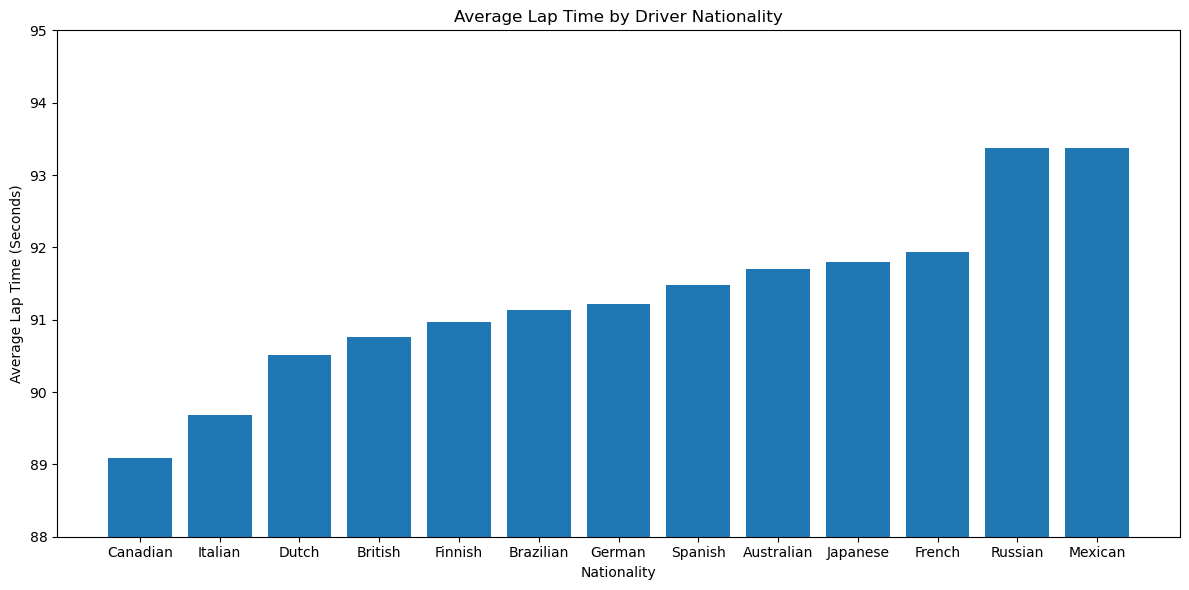

In [8]:
# Lets Visualize the data
# The x-axis is our index (the nationalities), the y-axis is the 'mean' column
plt.figure(figsize=(12, 6))
plt.bar(nation_table.index, nation_table['mean'])
plt.title('Average Lap Time by Driver Nationality')
plt.xlabel('Nationality')
plt.ylabel('Average Lap Time (Seconds)')
plt.ylim(88, 95)
plt.tight_layout()

plt.show()

# Analyzing Driver Age and Performance

### Age vs Performance Analysis
To look at how the age of a  Formula 1 driver affects their performance, we need to calculate their exact age on the day they drove the lap. To do this, we need to merge our current dataset with the "races.csv" file using an inner join on "raceId" to find the date of the event. By subtracting the driver's date of birth from the race date, we can group normal racing laps by age and see the actual performance trend.

In [9]:
# I also now want to look at the relationship between a drivers age and they're performance
# Let's load in the races dataset
races = pd.read_csv("f1_data/races.csv")

# Realistically we only need the raceId and date columns
races_clean = races[["raceId","date"]]

# Now we convert the date into a datetime format again (cleaning data)
races_clean['date'] = pd.to_datetime(races_clean['date'])

# Let's merge this with our dataset
f1_data = pd.merge(f1_data, races_clean, on='raceId', how='inner')

# Now we need to actually need to find a drivers age
# We can substract the date of the event from the drivers dob and then convert it to years
# (I'm dividing by 365.25 because using leap years that the average amount of days in a year)
f1_data['driver_age'] = (f1_data['date'] - f1_data['dob']).dt.days / 365.25

# Let's also round the age down to the nearest whole number
f1_data['age_years'] = np.floor(f1_data['driver_age'])

display(f1_data)

C:\Users\aleca\AppData\Local\Temp\ipykernel_18096\3538313541.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  races_clean['date'] = pd.to_datetime(races_clean['date'])


,raceId,driverId,lap,position,time,milliseconds,seconds,driverRef,number,code,forename,surname,dob,nationality,date,driver_age,age_years
0,841,20,1,1,1:38.109,98109,98.109,vettel,5.0,VET,Sebastian,Vettel,1987-07-03,German,2011-03-27,23.731691,23.0
1,841,20,2,1,1:33.006,93006,93.006,vettel,5.0,VET,Sebastian,Vettel,1987-07-03,German,2011-03-27,23.731691,23.0
2,841,20,3,1,1:32.713,92713,92.713,vettel,5.0,VET,Sebastian,Vettel,1987-07-03,German,2011-03-27,23.731691,23.0
3,841,20,4,1,1:32.803,92803,92.803,vettel,5.0,VET,Sebastian,Vettel,1987-07-03,German,2011-03-27,23.731691,23.0
4,841,20,5,1,1:32.342,92342,92.342,vettel,5.0,VET,Sebastian,Vettel,1987-07-03,German,2011-03-27,23.731691,23.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
528780,1086,842,65,13,1:25.989,85989,85.989,gasly,10.0,GAS,Pierre,Gasly,1996-02-07,French,2022-07-31,26.477755,26.0
528781,1086,842,66,12,1:25.187,85187,85.187,gasly,10.0,GAS,Pierre,Gasly,1996-02-07,French,2022-07-31,26.477755,26.0
528782,1086,842,67,12,1:47.355,107355,107.355,gasly,10.0,GAS,Pierre,Gasly,1996-02-07,French,2022-07-31,26.477755,26.0
528783,1086,842,68,12,1:37.587,97587,97.587,gasly,10.0,GAS,Pierre,Gasly,1996-02-07,French,2022-07-31,26.477755,26.0


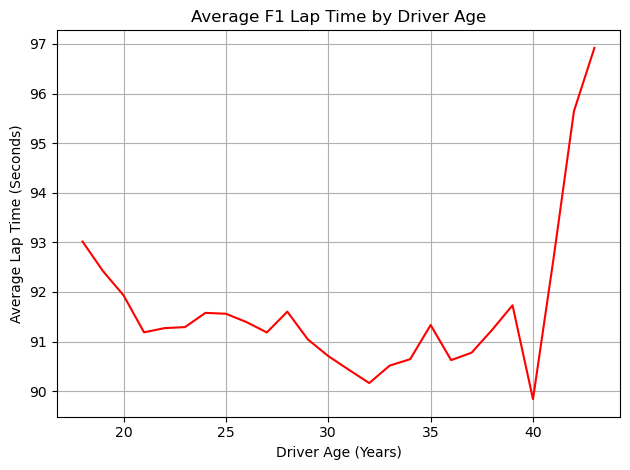

In [10]:
# Ok now lets do some analysis like before
# Filter only the normal laps
clean_laps = f1_data[f1_data['seconds'] < 120]

# Filter for only normal racing years. Maybe remove some outliers in,
# so keep in the ages 18 to 45 only so it doesn't ruin the data
age_filtered = clean_laps[(clean_laps['age_years'] >= 18) & (clean_laps['age_years'] <= 45)]

# Again, let's group the data by age to find the average lap time for each age group
age_table = age_filtered.groupby('age_years')['seconds'].mean()

# Now we make the plot
plt.plot(age_table.index, age_table.values, color = "red")
plt.title('Average F1 Lap Time by Driver Age')
plt.xlabel('Driver Age (Years)')
plt.ylabel('Average Lap Time (Seconds)') 
plt.tight_layout()
plt.grid(True)
plt.show()

## 4. Discussion
In this project, we successfully combined and manipulated multiple datasets to find historical trends in F1 racing. 

Our analysis showed that **Canadian** and **Italian** drivers hold the fastest average lap times in the sport's history, both averaging under 90 seconds for a normal racing lap. However, it is also important to note the impact of sample size: **German** and **British** drivers have recorded a lot more laps than any other nationality (over 70,000 laps each) and they still have a very competitive average of around 91 seconds.

Furthermore, our analysis also gave important insights in regards to the correclation between a dirvers age and their perforance. By visualizing average lap times across a driver's lifespan, we can see that drivers usually perform their best between the ages of **26 and 32**. This represents a peak perforance range where the benefits of being young intersect with the experience of a driver. Younger drivers and older drivers both display slightly slower average paces by comparison.